# CNN for the Detection of Plant Pathologies.

In [1]:
# Intalación de dependencias.
!pip -q install optuna
!pip -q install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 9.3 MB/s eta 0:00:00


In [2]:
# Impotamos librerías a utilizar.
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import wandb
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger

import optuna

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

In [3]:
# Importamos los datos del drive de colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
os.environ["WANDB_API_KEY"] = "0df13b0c5c253813bd9eb5bfff98fdfb82fa37d0"

In [5]:
wandb.login(key=os.getenv("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emilio-soto (emilio-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# Ordenamos los datos.
data_path = "/content/drive/MyDrive/Redes neuronales/Tarea 6. Identificación de enfermedad de una planta/data"
image_dir = f"{data_path}/images"
csv_path = f"{data_path}/train.csv"

# Visualizamos.
df = pd.read_csv(csv_path)
df.head(8)

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
5,Train_5,1,0,0,0
6,Train_6,0,1,0,0
7,Train_7,0,0,0,1


In [7]:
# Convertimos a one hot encoding en una sola columna.
label_columns = ['healthy', 'multiple_diseases', 'rust', 'scab']
df['label'] = df[label_columns].idxmax(axis=1)

In [8]:
# Revisamos las imágenes por clase.
print("Conteo de imágenes por clase:")
print(df['label'].value_counts())

Conteo de imágenes por clase:
label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64


In [9]:
# Agregamos la extensión .jpg a las imagenes.
if not df['image_id'].str.contains('.jpg').any():
    print("Añadimos extensión .jpg a 'image_id'...")
    df['image_id'] = df['image_id'] + '.jpg'
else:
    print("'image_id' ya tiene la extensión .jpg.")

Añadimos extensión .jpg a 'image_id'...


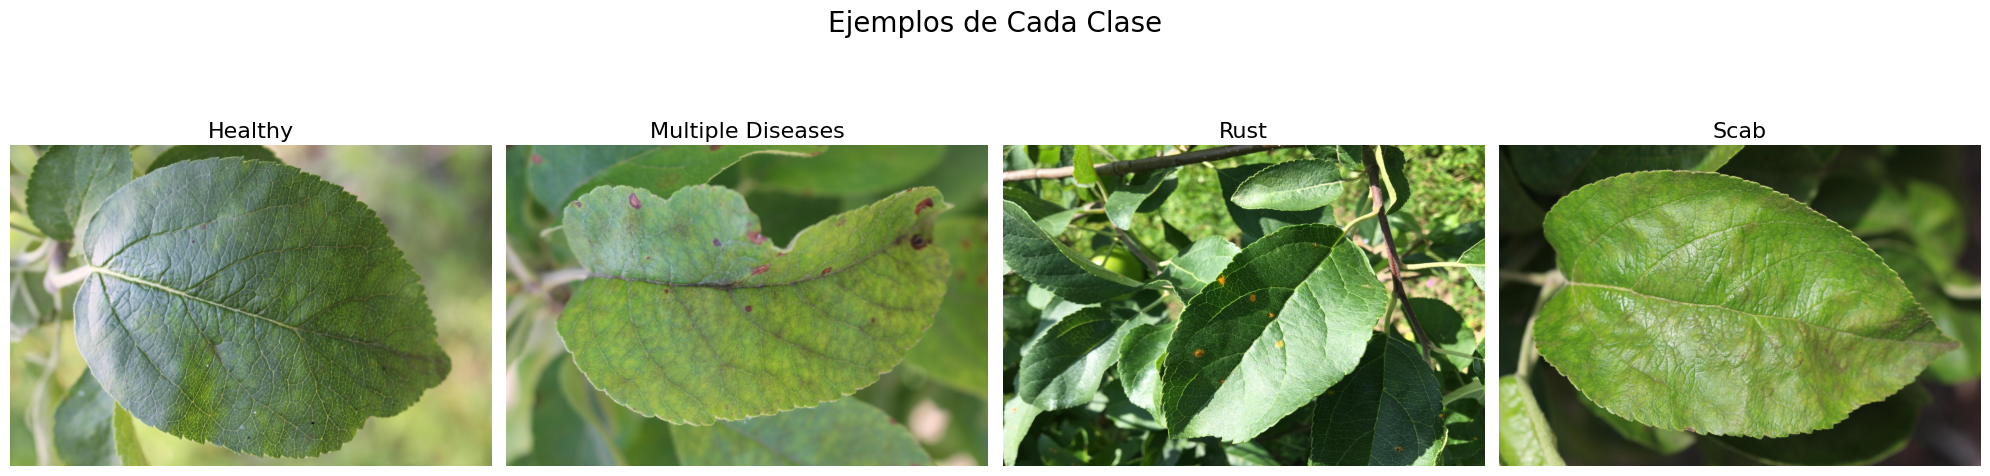

In [10]:
# Guardamos los nombres de una imagen de cada clase.
samples = {}
for label in label_columns:
    img_id = df[df[label] == 1].iloc[2]['image_id']
    samples[label] = img_id

# Graficamos un ejemplo de cada clase.
plt.figure(figsize=(20, 5))

# Para Healthy.
plt.subplot(1, 4, 1)
img = load_img(os.path.join(image_dir, samples['healthy']))
plt.imshow(img)
plt.title('Healthy', fontsize=16)
plt.axis('off')

# Para Multiple Diseases.
plt.subplot(1, 4, 2)
img = load_img(os.path.join(image_dir, samples['multiple_diseases']))
plt.imshow(img)
plt.title('Multiple Diseases', fontsize=16)
plt.axis('off')

# Para Rust.
plt.subplot(1, 4, 3)
img = load_img(os.path.join(image_dir, samples['rust']))
plt.imshow(img)
plt.title('Rust', fontsize=16)
plt.axis('off')

# Para Scab.
plt.subplot(1, 4, 4)
img = load_img(os.path.join(image_dir, samples['scab']))
plt.imshow(img)
plt.title('Scab', fontsize=16)
plt.axis('off')

plt.suptitle('Ejemplos de Cada Clase', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [11]:
# División de datos.
# Separamos el test.
main_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])

# El resto lo separamos entre entrenamiento y validación.
train_df, val_df = train_test_split(main_df, test_size=0.20, random_state=42, stratify=main_df['label'])

In [12]:
# Etiquetas del set de entrenamiento.
y_train_labels = train_df['label']

# Calculamos los pesos de forma 'balanced' para que las clases con menos muestras tengan un peso mayor.
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels)


clases_ordenadas = np.unique(y_train_labels)
class_indices = {label: i for i, label in enumerate(clases_ordenadas)}

print("Índices de clases (calculados):", class_indices)
class_weight_dict = {class_indices[label]: weight for label, weight in zip(clases_ordenadas, class_weights)}
print("Pesos calculados para el modelo: \n", class_weight_dict)

Índices de clases (calculados): {'healthy': 0, 'multiple_diseases': 1, 'rust': 2, 'scab': 3}
Pesos calculados para el modelo: 
 {0: np.float64(0.8814878892733564), 1: np.float64(4.995098039215686), 2: np.float64(0.7320402298850575), 3: np.float64(0.7696374622356495)}


In [13]:
# Definimos el tamaño de las imagenes y el tamaño del batch.
IMG_SIZE = (320, 320)
BATCH_SIZE = 32
NUM_CLASSES = 4

# Creamos los generadores.
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen_augmented.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42)

validation_dataset = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

Found 1019 validated image filenames belonging to 4 classes.
Found 255 validated image filenames belonging to 4 classes.


In [32]:
# Colocamos configuración del entrenamiento del clasificador.
config_fase1 = {
    "learning_rate": 1e-4,
    "architecture": "EfficientNetV2S_frozen",
    "head_dense_units": 512,
    "head_dropout": 0.35,
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "optimizer": "Adam"}

In [33]:
# Iniciamos trial.
wandb.init(
    project="Plant-Pathology-CNN",
    name="Entrenamiento de clasificador",
    config=config_fase1,
    reinit=True)

epoch/accuracy,▂▂▅▃▅▇█▃▅▅▁▇█
epoch/epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▄▄▂▂▃▁▃▃▂
epoch/val_accuracy,▅▅▄▃▆▂▆▁▇▆██▅
epoch/val_loss,▆▆▆▆▅▆▅█▄▄▁▃▄
epoch/accuracy,0.31992
epoch/epoch,12
epoch/learning_rate,0.0001
epoch/loss,1.47815
epoch/val_accuracy,0.38431


In [14]:
# Modelo base.
base_model = EfficientNetV2S(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet")
base_model.trainable = False

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
# Construimos el clasificador.
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [35]:
# Compilamos.
head_lr = 1e-4
model.compile(
    optimizer=Adam(learning_rate=head_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [36]:
# Callbacks
callbacks_fase1 = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        filepath='best_head_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1)]

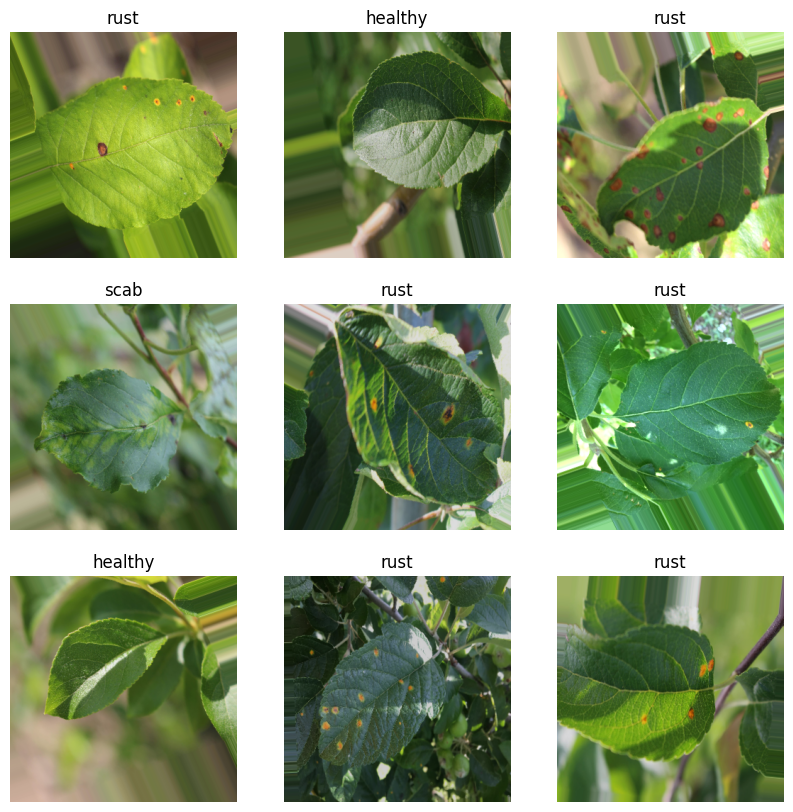

In [23]:
# Obtenemos un batch de imágenes y etiquetas del generador.
image_batch, label_batch = next(train_dataset)
class_names = list(train_dataset.class_indices.keys())

# Mostramos algunas imágenes aumentadas.
n = 9
plt.figure(figsize=(10, 10))
for i in range(n):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i])
    plt.title(class_names[label_batch[i].argmax()])
    plt.axis("off")
plt.show()

In [37]:
# Entrenamos.
history_class = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=60,
    callbacks=callbacks_fase1)
wandb.finish()

Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2882 - loss: 1.6779
Epoch 1: val_accuracy improved from -inf to 0.40784, saving model to best_head_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.2880 - loss: 1.6770 - val_accuracy: 0.4078 - val_loss: 1.3630
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3567 - loss: 1.5028
Epoch 2: val_accuracy did not improve from 0.40784
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.3559 - loss: 1.5029 - val_accuracy: 0.3490 - val_loss: 1.3560
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3246 - loss: 1.5269
Epoch 3: val_accuracy did not improve from 0.40784
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3250 - loss: 1.5263 - val_accuracy: 0.3961 - val_loss: 1.3169
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3746 - loss: 1.4194
Epoch 4: val_accuracy did not improve from 0.40784
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.3739 - loss: 1.4206 - val

epoch/accuracy,▁▃▃▄▄▅▄▅▅▆▄▅▆▇▆▅▆▆▇▇▇▆▆█▆▇▅▆▆▆▆█▇▇▇
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▃▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▂▂▁▂▂▂▁▂▁▁
epoch/val_accuracy,▄▁▃▃▂▄▆▅▄▅▄▆▇▇▆▅▃▄▇▄▆▇▄▇█▇▅▆▄▅▆▅▅▁▇
epoch/val_loss,██▇▆▆▆▅▅▄▅▄▃▃▂▃▄▅▄▂▅▂▂▄▃▁▁▂▂▄▂▂▃▄▅▁
epoch/accuracy,0.42591
epoch/epoch,34
epoch/learning_rate,0.0001
epoch/loss,1.23555
epoch/val_accuracy,0.48627


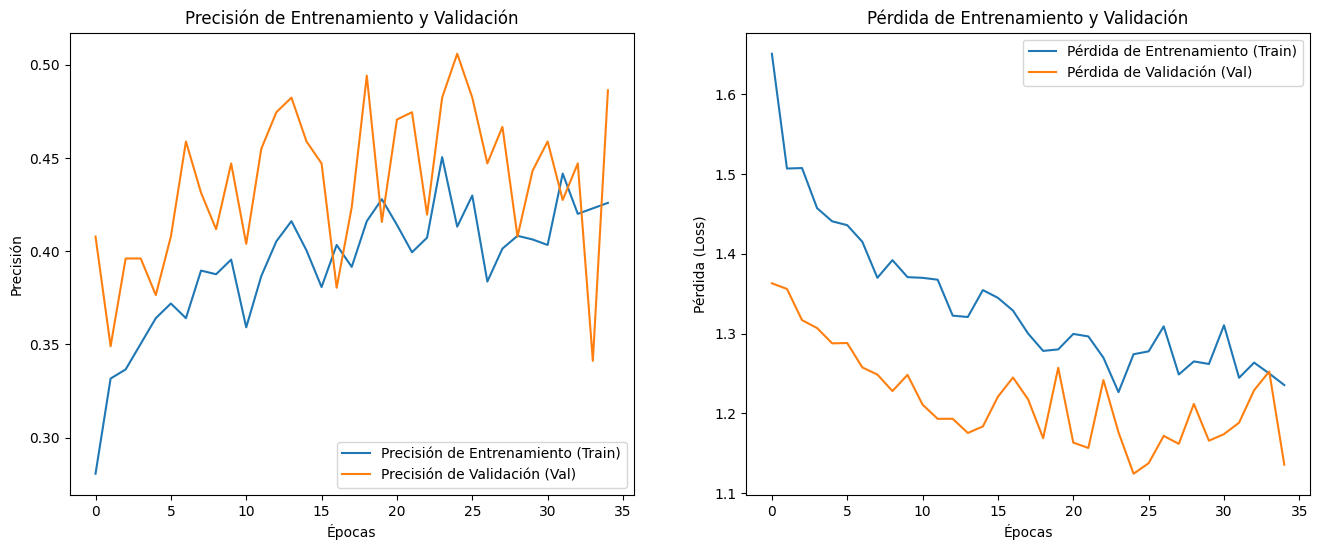

In [38]:
# Extraemos los datos del historial de entrenamiento.
acc = history_class.history['accuracy']
val_acc = history_class.history['val_accuracy']
loss = history_class.history['loss']
val_loss = history_class.history['val_loss']

# Contamos el número de épocas que corrió.
epochs_range = range(len(acc))

# Graficamos.
plt.figure(figsize=(16, 6))

# Gráfica de Precisión.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión de Entrenamiento (Train)')
plt.plot(epochs_range, val_acc, label='Precisión de Validación (Val)')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')

# Gráfica de Pérdida.
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de Entrenamiento (Train)')
plt.plot(epochs_range, val_loss, label='Pérdida de Validación (Val)')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.show()

In [40]:
# Guardamos el modelo.
model_save_path = "/content/drive/MyDrive/Redes neuronales/Tarea 6. Identificación de enfermedad de una planta/EffNetV2S_head_trained.keras"
model.save(model_save_path)